# Mini Project: Student Performance Analysis


Columns in Data

Categorical → gender, race/ethnicity, parental level of education, lunch, test preparation course

Numerical → math score, reading score, writing score

# Part A :  Basic EDA (Exploration)

In [1]:
import pandas as pd

df= pd.read_csv('/content/stud.csv')

In [3]:
#  Display the first 10 rows of the dataset.
df.head(10)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
5,female,group B,associate's degree,standard,none,71,83,78
6,female,group B,some college,standard,completed,88,95,92
7,male,group B,some college,free/reduced,none,40,43,39
8,male,group D,high school,free/reduced,completed,64,64,67
9,female,group B,high school,free/reduced,none,38,60,50


In [4]:
# Show the shape of the dataset (rows, columns).

df.shape

(1000, 8)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race_ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   math_score                   1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [6]:
# Check for missing values.
df.isnull().sum()

,0
gender,0
race_ethnicity,0
parental_level_of_education,0
lunch,0
test_preparation_course,0
math_score,0
reading_score,0
writing_score,0


In [9]:
# Get summary statistics (.describe()) of numeric columns.
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [11]:
# Count unique values in each categorical column.
col= df.columns

In [16]:
categorical_columns= col[0:5]

In [18]:
categorical_columns

Index(['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course'],
      dtype='object')

In [24]:
for x in categorical_columns:
  print(x,"    : ",df[x].unique(),"Count :   ",df[x].nunique())
  print('\n')

gender     :  ['female' 'male'] Count :    2


race_ethnicity     :  ['group B' 'group C' 'group A' 'group D' 'group E'] Count :    5


parental_level_of_education     :  ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school'] Count :    6


lunch     :  ['standard' 'free/reduced'] Count :    2


test_preparation_course     :  ['none' 'completed'] Count :    2




In [17]:
df['gender'].unique()

array(['female', 'male'], dtype=object)

In [ ]:
# Count unique values in each categorical column.


# Part B - Intermediate Analysis

In [27]:
# Find the average score in each subject grouped by gender.

df.groupby('gender')[["math_score","reading_score","writing_score"]].mean()

,math_score,reading_score,writing_score
gender,,,
female,63.633205,72.608108,72.467181
male,68.728216,65.473029,63.311203


In [29]:
#Compare average math score between students who completed the test preparation course and those who didn’t.
df.groupby('test_preparation_course')['math_score'].mean()

,math_score
test_preparation_course,
completed,69.695531
none,64.077882


In [33]:
# Which race/ethnicity group has the highest average writing score?

df_new = df.groupby('race_ethnicity')["writing_score"].mean()
result= df_new.reset_index()
result.sort_values('writing_score',ascending=False)


,race_ethnicity,writing_score
4,group E,71.407143
3,group D,70.145038
2,group C,67.827586
1,group B,65.600000
0,group A,62.674157


In [ ]:
# Find the top 5 students based on average of all three scores.

In [34]:
df['Average']= df[["math_score","reading_score","writing_score"]].mean(axis=1)

In [39]:
df.sort_values('Average',ascending=False).head(5)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,Average,total
916,male,group E,bachelor's degree,standard,completed,100,100,100,100.000000,300
962,female,group E,associate's degree,standard,none,100,100,100,100.000000,300
458,female,group E,bachelor's degree,standard,none,100,100,100,100.000000,300
114,female,group E,bachelor's degree,standard,completed,99,100,100,99.666667,299
712,female,group D,some college,standard,none,98,100,99,99.000000,297


In [35]:
df

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,Average
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667
1,female,group C,some college,standard,completed,69,90,88,82.333333
2,female,group B,master's degree,standard,none,90,95,93,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333
4,male,group C,some college,standard,none,76,78,75,76.333333
...,...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95,94.000000
996,male,group C,high school,free/reduced,none,62,55,55,57.333333
997,female,group C,high school,free/reduced,completed,59,71,65,65.000000
998,female,group D,some college,standard,completed,68,78,77,74.333333


In [36]:
df['total']= df['math_score']+df['reading_score']+df['writing_score']

df['avg']= df['total']

# Part C : Visual EDA

<Axes: xlabel='math_score', ylabel='Density'>

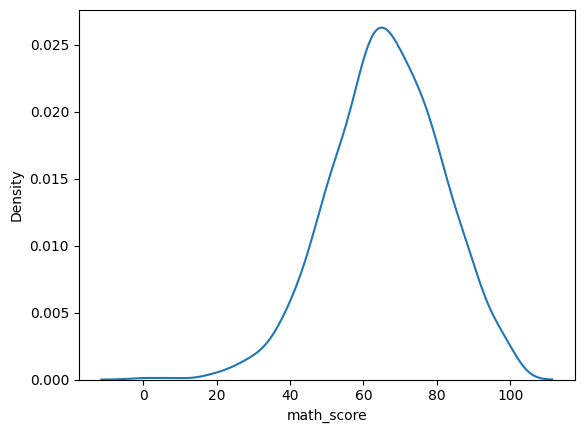

In [40]:
 #Check distribution of math score in data using kde
 # kde : kernel density estimation
 import seaborn as sns
 sns.kdeplot(df['math_score'])

<Axes: xlabel='gender', ylabel='count'>

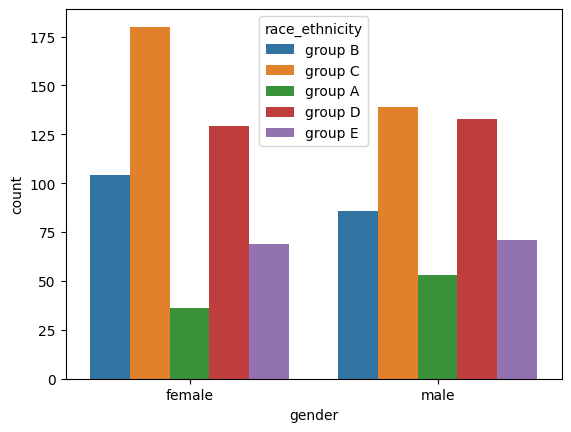

In [41]:
 # Check and plot genderwise count of student separated by ethnic group
sns.countplot(x='gender',data=df,hue='race_ethnicity')

# Part D  Tricky / Deeper Analysis

In [43]:
#Do students with standard lunch perform better than those with free/reduced lunch? (check with group means).
df.groupby('lunch')[["math_score","reading_score","writing_score"]].mean()

,math_score,reading_score,writing_score
lunch,,,
free/reduced,58.921127,64.653521,63.022535
standard,70.034109,71.654264,70.823256


In [44]:
# Which subject has the highest average difference between male and female students?
df.groupby('gender')[["math_score","reading_score","writing_score"]].mean()

,math_score,reading_score,writing_score
gender,,,
female,63.633205,72.608108,72.467181
male,68.728216,65.473029,63.311203


In [47]:
# Find students who scored above 90 in all three subjects
df[(df['math_score']>90) & (df['reading_score']>90) & (df['writing_score']>90)]

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,Average,total
114,female,group E,bachelor's degree,standard,completed,99,100,100,99.666667,299
149,male,group E,associate's degree,free/reduced,completed,100,100,93,97.666667,293
165,female,group C,bachelor's degree,standard,completed,96,100,100,98.666667,296
179,female,group D,some high school,standard,completed,97,100,100,99.000000,297
451,female,group E,some college,standard,none,100,92,97,96.333333,289
458,female,group E,bachelor's degree,standard,none,100,100,100,100.000000,300
546,female,group A,some high school,standard,completed,92,100,97,96.333333,289
566,female,group E,bachelor's degree,free/reduced,completed,92,100,100,97.333333,292
571,male,group A,bachelor's degree,standard,none,91,96,92,93.000000,279
594,female,group C,bachelor's degree,standard,completed,92,100,99,97.000000,291


In [48]:
# Among different parental education levels, which children perform best on average?

df.groupby('parental_level_of_education')[["math_score","reading_score","writing_score"]].mean()


,math_score,reading_score,writing_score
parental_level_of_education,,,
associate's degree,67.882883,70.927928,69.896396
bachelor's degree,69.389831,73.000000,73.381356
high school,62.137755,64.704082,62.448980
master's degree,69.745763,75.372881,75.677966
some college,67.128319,69.460177,68.840708
some high school,63.497207,66.938547,64.888268


#  Insigts

In [ ]:
 1  .  Students whose parents have higher education level generally score better

In [ ]:
 2 .  Parent education shows positive corretion

In [ ]:
3 .  Students with standard lunch  tend to perform better  than those with free lunch

In [ ]:
4  .  Student who completed test prepration  scored higher than other student

In [ ]:
5  .   Female student tend to outperform  male student in  writing score    ,
          While male student score higher in math .

In [ ]:
6 . Group E scored higher than other groups

In [2]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [ ]:
Plot a histogram of math scores.

Create a boxplot of writing scores by gender.

Draw a countplot of parental education levels.

Make a pairplot of math, reading, and writing scores to check relationships.

Plot a heatmap of correlations between scores.